# Section 8: Selecting Evaluation Metrics

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    log_loss,
    brier_score_loss,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    roc_curve,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

In [2]:
print('Fetching Titanic dataset from OpenML...')
titanic = fetch_openml(name='titanic', version=1, as_frame=True, parser='auto')
titanic_df = titanic.frame

# 2. Load LendingClub Dataset via OpenML

print('Fetching LendingClub dataset from OpenML...')
lending = fetch_openml(name='lending-club-loan-data', version=1, as_frame=True, parser='auto')
lending_df = lending.frame

print('Datasets loaded successfully!')

Fetching Titanic dataset from OpenML...
Fetching LendingClub dataset from OpenML...
Datasets loaded successfully!


### Evaluation Metrics: Titanic

Titanic is a binary classification problem.

Target:

- `survived = 0`: did not survive
- `survived = 1`: survived

Useful metrics:

1. Accuracy  
2. Precision  
3. Recall  
4. F1-score  
5. ROC-AUC  
6. PR-AUC  
7. Log Loss  
8. Brier Score  
9. Confusion Matrix  

In [ ]:
titanic_model = titanic_df.copy()

target_col = "survived"

# Convert target to integer
titanic_model[target_col] = titanic_model[target_col].astype(int)

# Treat pclass as categorical
if "pclass" in titanic_model.columns:
    titanic_model["pclass"] = titanic_model["pclass"].astype("category")

# Separate features and target first
X_titanic = titanic_model.drop(columns=[target_col]).copy()
y_titanic = titanic_model[target_col].copy()

# Drop leakage or high-cardinality columns
cols_to_drop = ["name", "ticket", "cabin", "boat", "body", "home.dest"]
X_titanic = X_titanic.drop(columns=cols_to_drop, errors="ignore")

# Identify categorical and numeric columns
cat_cols = X_titanic.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
num_cols = X_titanic.select_dtypes(include=[np.number]).columns.tolist()

# Clean categorical columns
for col in cat_cols:
    X_titanic[col] = X_titanic[col].astype("object")
    X_titanic[col] = X_titanic[col].fillna("missing")
    X_titanic[col] = X_titanic[col].astype(str).str.strip().str.lower()

# One-hot encode categorical columns
X_titanic = pd.get_dummies(
    X_titanic,
    columns=cat_cols,
    drop_first=True,
    dtype=int
)

print("Titanic X shape:", X_titanic.shape)
print("Titanic y shape:", y_titanic.shape)

display(y_titanic.value_counts())
display(y_titanic.value_counts(normalize=True))

In [4]:
# Train-test split

X_train_titanic, X_test_titanic, y_train_titanic, y_test_titanic = train_test_split(
    X_titanic,
    y_titanic,
    test_size=0.2,
    random_state=42,
    stratify=y_titanic
)

In [ ]:
# Train a logistic regression model

titanic_clf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

titanic_clf.fit(X_train_titanic, y_train_titanic)

y_pred_titanic = titanic_clf.predict(X_test_titanic)
y_proba_titanic = titanic_clf.predict_proba(X_test_titanic)[:, 1]

### Basic Classification Metrics

Accuracy is useful when classes are balanced.

Precision and recall are more useful when one type of mistake matters more.

In [6]:
titanic_metrics = {
    "accuracy": accuracy_score(y_test_titanic, y_pred_titanic),
    "precision": precision_score(y_test_titanic, y_pred_titanic),
    "recall": recall_score(y_test_titanic, y_pred_titanic),
    "f1": f1_score(y_test_titanic, y_pred_titanic),
    "roc_auc": roc_auc_score(y_test_titanic, y_proba_titanic),
    "pr_auc": average_precision_score(y_test_titanic, y_proba_titanic),
    "log_loss": log_loss(y_test_titanic, y_proba_titanic),
    "brier_score": brier_score_loss(y_test_titanic, y_proba_titanic)
}

titanic_metrics_df = pd.DataFrame([titanic_metrics]).T.reset_index()
titanic_metrics_df.columns = ["metric", "value"]

display(titanic_metrics_df)

,metric,value
0,accuracy,0.805344
1,precision,0.763441
2,recall,0.710000
3,f1,0.735751
4,roc_auc,0.867253
5,pr_auc,0.831397
6,log_loss,0.433410
7,brier_score,0.135610


In [7]:
print("Titanic Classification Report:")
print(classification_report(y_test_titanic, y_pred_titanic))

Titanic Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.85       162
           1       0.76      0.71      0.74       100

    accuracy                           0.81       262
   macro avg       0.80      0.79      0.79       262
weighted avg       0.80      0.81      0.80       262



### Confusion Matrix

Confusion matrix shows:

- True negatives
- False positives
- False negatives
- True positives

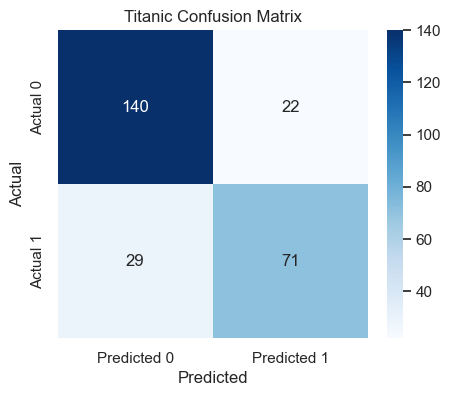

In [8]:
cm = confusion_matrix(y_test_titanic, y_pred_titanic)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted 0", "Predicted 1"],
    yticklabels=["Actual 0", "Actual 1"]
)
plt.title("Titanic Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### ROC Curve

ROC curve shows the tradeoff between true positive rate and false positive rate.

ROC-AUC is useful when comparing ranking quality across thresholds.

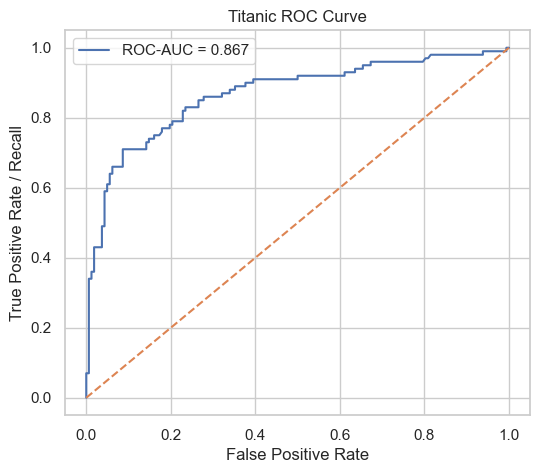

In [9]:
fpr, tpr, roc_thresholds = roc_curve(y_test_titanic, y_proba_titanic)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc_score(y_test_titanic, y_proba_titanic):.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Recall")
plt.title("Titanic ROC Curve")
plt.legend()
plt.show()

### Precision-Recall Curve

Precision-recall curve is especially useful when the positive class is rare.

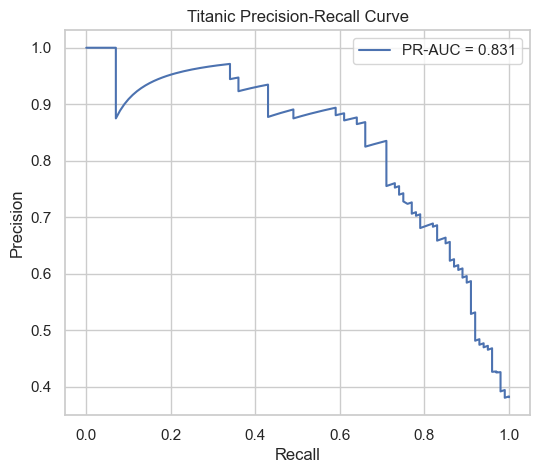

In [10]:
precision, recall, pr_thresholds = precision_recall_curve(
    y_test_titanic,
    y_proba_titanic
)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f"PR-AUC = {average_precision_score(y_test_titanic, y_proba_titanic):.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Titanic Precision-Recall Curve")
plt.legend()
plt.show()

### Threshold Tuning

Default classification threshold is usually 0.5.

But depending on business needs, we may choose a different threshold.

In [11]:
def evaluate_thresholds(y_true, y_proba, thresholds):
    rows = []
    
    for threshold in thresholds:
        y_pred_threshold = (y_proba >= threshold).astype(int)
        
        rows.append({
            "threshold": threshold,
            "accuracy": accuracy_score(y_true, y_pred_threshold),
            "precision": precision_score(y_true, y_pred_threshold, zero_division=0),
            "recall": recall_score(y_true, y_pred_threshold, zero_division=0),
            "f1": f1_score(y_true, y_pred_threshold, zero_division=0)
        })
    
    return pd.DataFrame(rows)

thresholds = np.arange(0.1, 0.91, 0.05)

titanic_threshold_results = evaluate_thresholds(
    y_test_titanic,
    y_proba_titanic,
    thresholds
)

display(titanic_threshold_results.head())

,threshold,accuracy,precision,recall,f1
0,0.10,0.507634,0.434389,0.96,0.598131
1,0.15,0.645038,0.519774,0.92,0.664260
2,0.20,0.717557,0.583333,0.91,0.710938
3,0.25,0.751908,0.625899,0.87,0.728033
4,0.30,0.770992,0.658730,0.83,0.734513


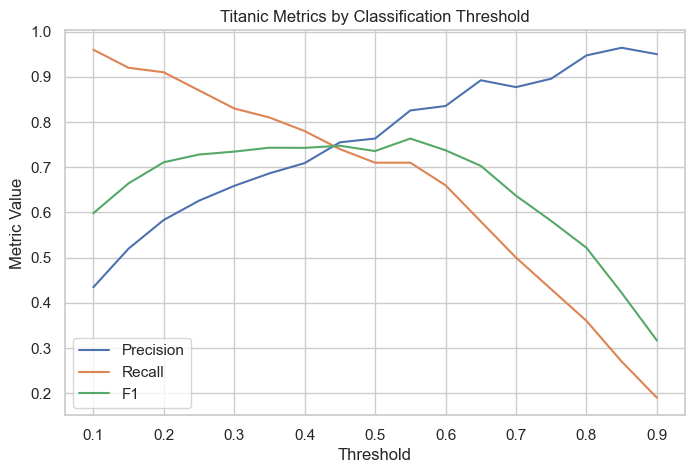

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(titanic_threshold_results["threshold"], titanic_threshold_results["precision"], label="Precision")
plt.plot(titanic_threshold_results["threshold"], titanic_threshold_results["recall"], label="Recall")
plt.plot(titanic_threshold_results["threshold"], titanic_threshold_results["f1"], label="F1")
plt.xlabel("Threshold")
plt.ylabel("Metric Value")
plt.title("Titanic Metrics by Classification Threshold")
plt.legend()
plt.show()

# LendingClub Dataset

LendingClub is a binary classification problem.

Target:

- `not.fully.paid = 0`: fully paid
- `not.fully.paid = 1`: not fully paid

This is usually imbalanced, so accuracy can be misleading.

More useful metrics:

1. Precision  
2. Recall  
3. F1-score  
4. ROC-AUC  
5. PR-AUC  
6. Confusion matrix  
7. Business cost metrics  

In [ ]:
# ============================================================
# 8B. Prepare LendingClub Dataset
# ============================================================

lc_model = lending_df.copy()

target_col = "not.fully.paid"

# Convert target to integer
lc_model[target_col] = lc_model[target_col].astype(int)

# Separate features and target first
X_lc = lc_model.drop(columns=[target_col]).copy()
y_lc = lc_model[target_col].copy()

# Identify categorical and numeric columns
cat_cols = X_lc.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
num_cols = X_lc.select_dtypes(include=[np.number]).columns.tolist()

# Clean categorical columns
for col in cat_cols:
    X_lc[col] = X_lc[col].astype("object")
    X_lc[col] = X_lc[col].fillna("missing")
    X_lc[col] = X_lc[col].astype(str).str.strip().str.lower()

# One-hot encode categorical columns
X_lc = pd.get_dummies(
    X_lc,
    columns=cat_cols,
    drop_first=True,
    dtype=int
)

# Replace infinite values with NaN before split (no statistical leakage)
X_lc = X_lc.replace([np.inf, -np.inf], np.nan)

print("LendingClub X shape:", X_lc.shape)
print("LendingClub y shape:", y_lc.shape)

display(y_lc.value_counts())
display(y_lc.value_counts(normalize=True))

In [17]:
# Train-test split

X_train_lc, X_test_lc, y_train_lc, y_test_lc = train_test_split(
    X_lc,
    y_lc,
    test_size=0.2,
    random_state=42,
    stratify=y_lc
)

In [ ]:
# Train weighted logistic regression because LendingClub is imbalanced

lc_clf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

lc_clf.fit(X_train_lc, y_train_lc)

y_pred_lc = lc_clf.predict(X_test_lc)
y_proba_lc = lc_clf.predict_proba(X_test_lc)[:, 1]

### Basic Metrics

For LendingClub, pay special attention to class `1`, which means not fully paid.

In [19]:
lc_metrics = {
    "accuracy": accuracy_score(y_test_lc, y_pred_lc),
    "precision": precision_score(y_test_lc, y_pred_lc, zero_division=0),
    "recall": recall_score(y_test_lc, y_pred_lc, zero_division=0),
    "f1": f1_score(y_test_lc, y_pred_lc, zero_division=0),
    "roc_auc": roc_auc_score(y_test_lc, y_proba_lc),
    "pr_auc": average_precision_score(y_test_lc, y_proba_lc),
    "log_loss": log_loss(y_test_lc, y_proba_lc),
    "brier_score": brier_score_loss(y_test_lc, y_proba_lc)
}

lc_metrics_df = pd.DataFrame([lc_metrics]).T.reset_index()
lc_metrics_df.columns = ["metric", "value"]

display(lc_metrics_df)

,metric,value
0,accuracy,0.640397
1,precision,0.239071
2,recall,0.570033
3,f1,0.336862
4,roc_auc,0.684468
5,pr_auc,0.302739
6,log_loss,0.634011
7,brier_score,0.220602


In [20]:
print("LendingClub Classification Report:")
print(classification_report(y_test_lc, y_pred_lc))

LendingClub Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.65      0.75      1609
           1       0.24      0.57      0.34       307

    accuracy                           0.64      1916
   macro avg       0.56      0.61      0.55      1916
weighted avg       0.78      0.64      0.69      1916



### Accuracy Baseline Problem

If the dataset is imbalanced, a model can get high accuracy by predicting only the majority class.

This example predicts all loans as fully paid.

In [21]:
# Majority-class baseline: predict everything as 0

y_pred_all_zero = np.zeros_like(y_test_lc)

baseline_metrics = {
    "accuracy": accuracy_score(y_test_lc, y_pred_all_zero),
    "precision": precision_score(y_test_lc, y_pred_all_zero, zero_division=0),
    "recall": recall_score(y_test_lc, y_pred_all_zero, zero_division=0),
    "f1": f1_score(y_test_lc, y_pred_all_zero, zero_division=0)
}

baseline_metrics_df = pd.DataFrame([baseline_metrics]).T.reset_index()
baseline_metrics_df.columns = ["metric", "all_zero_baseline"]

display(baseline_metrics_df)

,metric,all_zero_baseline
0,accuracy,0.83977
1,precision,0.00000
2,recall,0.00000
3,f1,0.00000


This shows why accuracy can be misleading for imbalanced classification.

### Confusion Matrix

For lending:

- False negative: predicted fully paid, actually not fully paid
- False positive: predicted risky, actually fully paid

False negatives may be more costly.

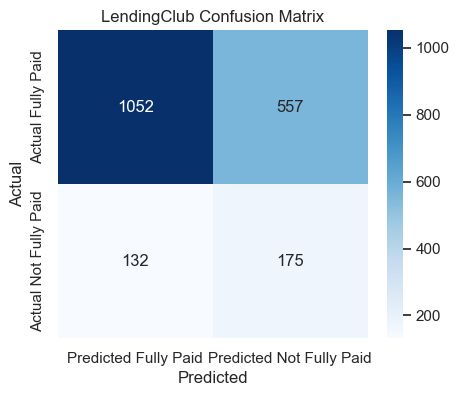

In [22]:
cm_lc = confusion_matrix(y_test_lc, y_pred_lc)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_lc,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Fully Paid", "Predicted Not Fully Paid"],
    yticklabels=["Actual Fully Paid", "Actual Not Fully Paid"]
)
plt.title("LendingClub Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### ROC Curve

ROC-AUC is useful for comparing overall ranking quality.

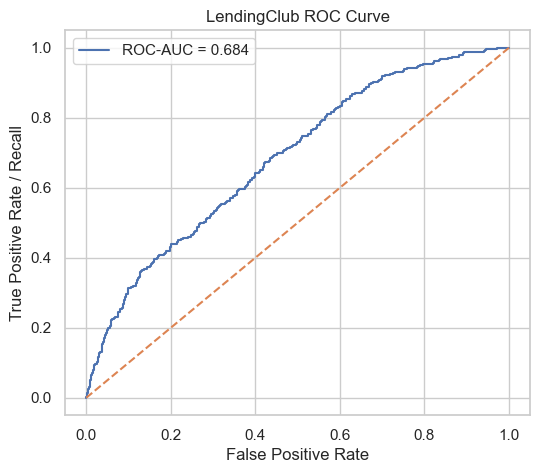

In [23]:
fpr_lc, tpr_lc, roc_thresholds_lc = roc_curve(y_test_lc, y_proba_lc)

plt.figure(figsize=(6, 5))
plt.plot(fpr_lc, tpr_lc, label=f"ROC-AUC = {roc_auc_score(y_test_lc, y_proba_lc):.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Recall")
plt.title("LendingClub ROC Curve")
plt.legend()
plt.show()

### Precision-Recall Curve

PR-AUC is often more informative than ROC-AUC when the positive class is rare.

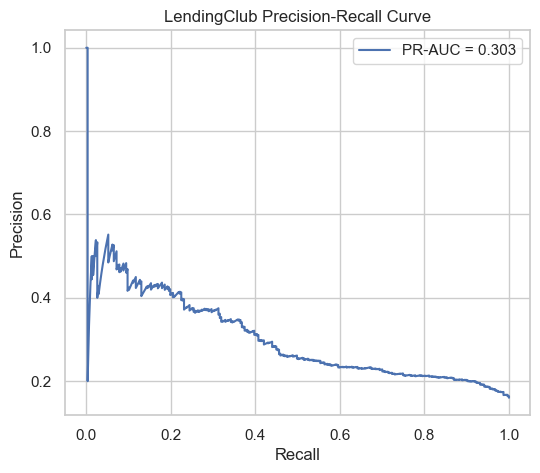

In [24]:
precision_lc, recall_lc, pr_thresholds_lc = precision_recall_curve(
    y_test_lc,
    y_proba_lc
)

plt.figure(figsize=(6, 5))
plt.plot(recall_lc, precision_lc, label=f"PR-AUC = {average_precision_score(y_test_lc, y_proba_lc):.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("LendingClub Precision-Recall Curve")
plt.legend()
plt.show()

### Threshold Tuning for LendingClub

For LendingClub, the default threshold of 0.5 may not be ideal.

Lower threshold:

- More loans classified as risky
- Higher recall
- Lower precision

Higher threshold:

- Fewer loans classified as risky
- Higher precision
- Lower recall

In [25]:
lc_threshold_results = evaluate_thresholds(
    y_test_lc,
    y_proba_lc,
    thresholds=np.arange(0.05, 0.96, 0.05)
)

display(lc_threshold_results)

,threshold,accuracy,precision,recall,f1
0,0.05,0.160230,0.160230,1.000000,0.276203
1,0.10,0.160752,0.160313,1.000000,0.276328
2,0.15,0.168058,0.161494,1.000000,0.278080
3,0.20,0.193111,0.165316,0.996743,0.283596
4,0.25,0.240605,0.172748,0.986971,0.294032
5,0.30,0.308455,0.182668,0.954397,0.306646
6,0.35,0.390919,0.198457,0.921824,0.326601
7,0.40,0.474948,0.210439,0.827362,0.335535
8,0.45,0.565762,0.225131,0.700326,0.340729
9,0.50,0.640397,0.239071,0.570033,0.336862


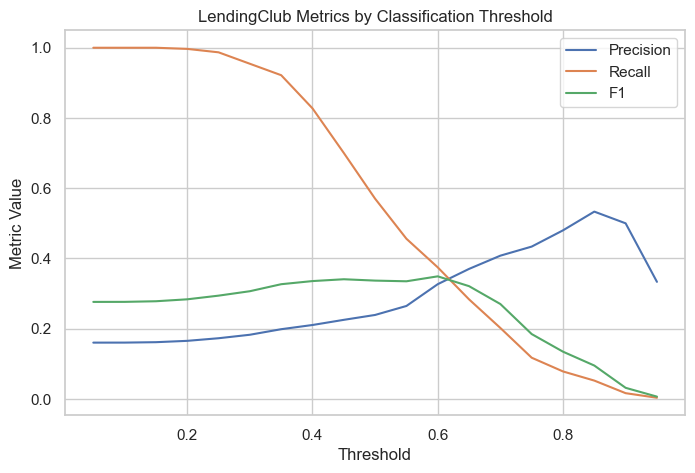

In [26]:
plt.figure(figsize=(8, 5))
plt.plot(lc_threshold_results["threshold"], lc_threshold_results["precision"], label="Precision")
plt.plot(lc_threshold_results["threshold"], lc_threshold_results["recall"], label="Recall")
plt.plot(lc_threshold_results["threshold"], lc_threshold_results["f1"], label="F1")
plt.xlabel("Threshold")
plt.ylabel("Metric Value")
plt.title("LendingClub Metrics by Classification Threshold")
plt.legend()
plt.show()

### Business Cost-Based Metric

Business problems often require custom metrics.

Example:

- False negative cost = 5  
  Model says loan is safe, but it is not fully paid.

- False positive cost = 1  
  Model says loan is risky, but it would have been fully paid.

In [27]:
def business_cost_metric(y_true, y_pred, false_negative_cost=5, false_positive_cost=1):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    false_negatives = ((y_true == 1) & (y_pred == 0)).sum()
    false_positives = ((y_true == 0) & (y_pred == 1)).sum()
    true_positives = ((y_true == 1) & (y_pred == 1)).sum()
    true_negatives = ((y_true == 0) & (y_pred == 0)).sum()
    
    total_cost = (
        false_negatives * false_negative_cost
        + false_positives * false_positive_cost
    )
    
    return {
        "true_positives": true_positives,
        "true_negatives": true_negatives,
        "false_positives": false_positives,
        "false_negatives": false_negatives,
        "total_business_cost": total_cost
    }

In [30]:
business_threshold_rows = []

for threshold in np.arange(0.05, 0.96, 0.05):
    y_pred_threshold = (y_proba_lc >= threshold).astype(int)
    
    cost_result = business_cost_metric(
        y_test_lc,
        y_pred_threshold,
        false_negative_cost=5,
        false_positive_cost=1
    )
    
    business_threshold_rows.append({
        "threshold": threshold,
        **cost_result
    })

business_threshold_df = pd.DataFrame(business_threshold_rows)

display(business_threshold_df.sort_values("total_business_cost").head(10).sort_values("threshold"))

,threshold,true_positives,true_negatives,false_positives,false_negatives,total_business_cost
5,0.30,293,298,1311,14,1381
6,0.35,283,466,1143,24,1263
7,0.40,254,656,953,53,1218
8,0.45,215,869,740,92,1200
9,0.50,175,1052,557,132,1217
10,0.55,140,1220,389,167,1224
11,0.60,115,1372,237,192,1197
12,0.65,87,1461,148,220,1248
13,0.70,62,1519,90,245,1315
14,0.75,36,1562,47,271,1402


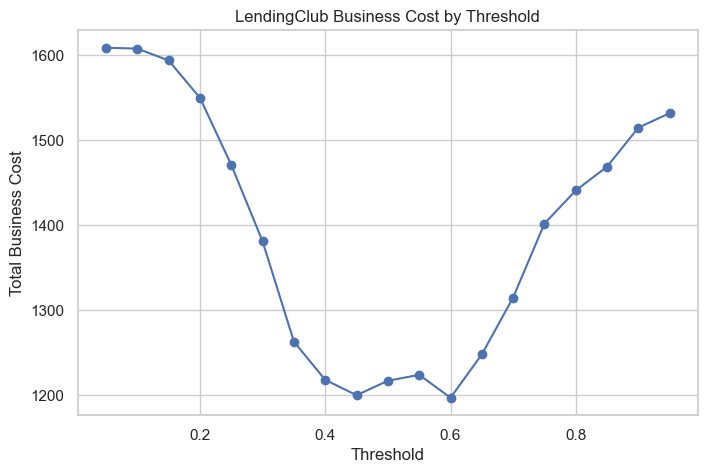

In [31]:
plt.figure(figsize=(8, 5))
plt.plot(
    business_threshold_df["threshold"],
    business_threshold_df["total_business_cost"],
    marker="o"
)
plt.xlabel("Threshold")
plt.ylabel("Total Business Cost")
plt.title("LendingClub Business Cost by Threshold")
plt.show()

## Regression Evaluation Metrics

The deck also includes regression metrics:

1. MAE  
2. MSE  
3. RMSE  
4. R-squared  

Titanic and LendingClub are classification examples, so we create a regression example using Titanic `fare`.

Target:

- Predict passenger fare

In [ ]:
# ============================================================
# 8C. Regression Metrics Example: Predict Titanic Fare
# ============================================================

reg_df = titanic_df.copy()

target_col = "fare"

reg_df = reg_df.dropna(subset=[target_col])

if "pclass" in reg_df.columns:
    reg_df["pclass"] = reg_df["pclass"].astype("category")

X_reg = reg_df.drop(columns=[target_col]).copy()
y_reg = reg_df[target_col].astype(float).copy()

# Drop leakage/unhelpful columns
cols_to_drop = ["name", "ticket", "cabin", "boat", "body", "home.dest", "survived"]
X_reg = X_reg.drop(columns=cols_to_drop, errors="ignore")

cat_cols = X_reg.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
num_cols = X_reg.select_dtypes(include=[np.number]).columns.tolist()

for col in cat_cols:
    X_reg[col] = X_reg[col].astype("object")
    X_reg[col] = X_reg[col].fillna("missing")
    X_reg[col] = X_reg[col].astype(str).str.strip().str.lower()

X_reg = pd.get_dummies(
    X_reg,
    columns=cat_cols,
    drop_first=True,
    dtype=int
)

print("Regression X shape:", X_reg.shape)
print("Regression y shape:", y_reg.shape)

In [33]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

In [ ]:
regression_models = {
    "Linear Regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "Ridge Regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ])
}

regression_results = []

for model_name, model in regression_models.items():
    model.fit(X_train_reg, y_train_reg)
    preds = model.predict(X_test_reg)

    regression_results.append({
        "model": model_name,
        "mae": mean_absolute_error(y_test_reg, preds),
        "mse": mean_squared_error(y_test_reg, preds),
        "rmse": np.sqrt(mean_squared_error(y_test_reg, preds)),
        "r2": r2_score(y_test_reg, preds)
    })

regression_results_df = pd.DataFrame(regression_results)

display(regression_results_df)

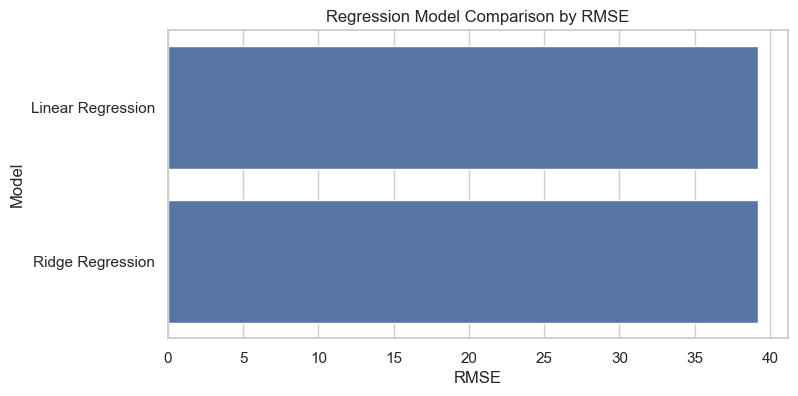

In [35]:
plt.figure(figsize=(8, 4))
sns.barplot(data=regression_results_df, x="rmse", y="model")
plt.title("Regression Model Comparison by RMSE")
plt.xlabel("RMSE")
plt.ylabel("Model")
plt.show()

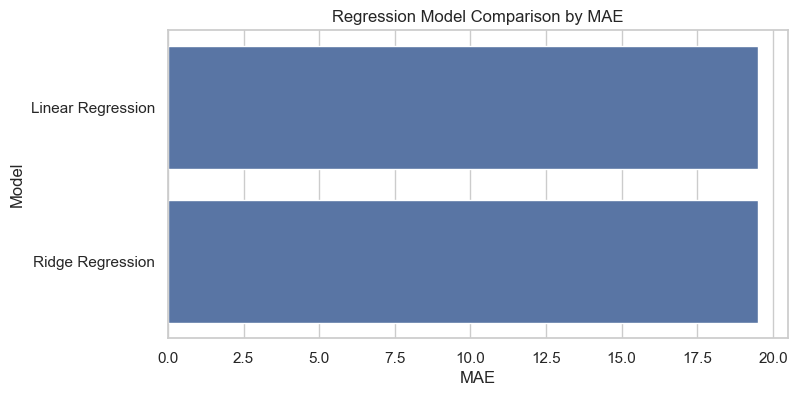

In [36]:
plt.figure(figsize=(8, 4))
sns.barplot(data=regression_results_df, x="mae", y="model")
plt.title("Regression Model Comparison by MAE")
plt.xlabel("MAE")
plt.ylabel("Model")
plt.show()

In [37]:
metric_recommendations = pd.DataFrame({
    "problem_type": [
        "Regression",
        "Regression with large errors important",
        "Balanced classification",
        "Imbalanced classification",
        "Risk detection / fraud / default",
        "Probability prediction",
        "Ranking / recommendation",
        "Business-cost-sensitive classification"
    ],
    "recommended_metrics": [
        "MAE, RMSE, R-squared",
        "RMSE, MSE",
        "Accuracy, ROC-AUC",
        "Precision, Recall, F1, PR-AUC",
        "Recall, Precision, F1, PR-AUC",
        "Log Loss, Brier Score",
        "Precision@K, Recall@K, NDCG, MAP, MRR",
        "Custom cost metric, threshold analysis"
    ],
    "why": [
        "Measures size of prediction errors",
        "Penalizes large errors heavily",
        "Classes are similar in size",
        "Accuracy can be misleading",
        "Positive class is rare and important",
        "Evaluates quality of predicted probabilities",
        "Evaluates ordering quality",
        "Different errors have different costs"
    ]
})

display(metric_recommendations)

,problem_type,recommended_metrics,why
0,Regression,"MAE, RMSE, R-squared",Measures size of prediction errors
1,Regression with large errors important,"RMSE, MSE",Penalizes large errors heavily
2,Balanced classification,"Accuracy, ROC-AUC",Classes are similar in size
3,Imbalanced classification,"Precision, Recall, F1, PR-AUC",Accuracy can be misleading
4,Risk detection / fraud / default,"Recall, Precision, F1, PR-AUC",Positive class is rare and important
5,Probability prediction,"Log Loss, Brier Score",Evaluates quality of predicted probabilities
6,Ranking / recommendation,"Precision@K, Recall@K, NDCG, MAP, MRR",Evaluates ordering quality
7,Business-cost-sensitive classification,"Custom cost metric, threshold analysis",Different errors have different costs


# Section 8 Summary

Key ideas:

- Accuracy is useful for balanced classification.
- Precision matters when false positives are costly.
- Recall matters when false negatives are costly.
- F1 balances precision and recall.
- ROC-AUC evaluates ranking quality across thresholds.
- PR-AUC is often better for imbalanced classification.
- Log Loss and Brier Score evaluate probability quality.
- MAE, MSE, RMSE, and R-squared are regression metrics.
- Business problems often require threshold tuning and custom cost metrics.

For Titanic:

- Accuracy, F1, and ROC-AUC are reasonable.

For LendingClub:

- Precision, recall, F1, PR-AUC, and business cost are more useful than accuracy alone.